# Subgraphs with Separate State

A LangGraph parent graph that calls a subgraph with its own, independent state schema. The parent answers a question in English, then hands the answer to a subgraph that translates it to Hindi.

## 1. Install required packages

In [1]:
%pip install -qU langgraph langchain-openai python-dotenv

Note: you may need to restart the kernel to use updated packages.


## 2. Setup & imports

In [2]:
import os

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError(
        "OPENAI_API_KEY not found. Add it to a .env file in this notebook's directory."
    )

## 3. Build the subgraph (translation)

The subgraph has its own state (`SubState`), completely separate from the parent graph's state — the parent maps its own fields into and out of it at the call site.

In [3]:
class SubState(TypedDict):
    input_text: str
    translated_text: str


subgraph_llm = ChatOpenAI(model="gpt-4o")


def translate_text(state: SubState):
    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {"translated_text": translated_text}


subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node("translate_text", translate_text)

subgraph_builder.add_edge(START, "translate_text")
subgraph_builder.add_edge("translate_text", END)

subgraph = subgraph_builder.compile()

## 4. Define the parent graph state & LLM

In [4]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str


parent_llm = ChatOpenAI(model="gpt-4o-mini")

## 5. Define the parent graph nodes

`translate_answer` is where the parent calls into the subgraph, translating between `ParentState` and `SubState` at the boundary.

In [5]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(
        f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}"
    ).content
    return {"answer_eng": answer}


def translate_answer(state: ParentState):
    # Call the subgraph, mapping parent state into its own SubState schema.
    result = subgraph.invoke({"input_text": state["answer_eng"]})
    return {"answer_hin": result["translated_text"]}

## 6. Build, compile & visualize the parent graph

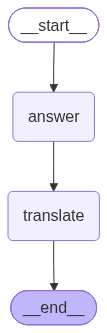

In [6]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, "answer")
parent_builder.add_edge("answer", "translate")
parent_builder.add_edge("translate", END)

graph = parent_builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 7. Run the graph

In [7]:
result = graph.invoke({"question": "What is quantum physics"})

print("--- English answer ---")
print(result["answer_eng"])
print("\n--- Hindi translation ---")
print(result["answer_hin"])

--- English answer ---
Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that deals with the behavior of matter and energy at very small scales, typically at the level of atoms and subatomic particles. It describes phenomena that classical physics cannot adequately explain, such as the behavior of electrons in atoms, the nature of light as both a wave and a particle, and the principles of superposition and entanglement.

Key features of quantum physics include:

1. **Quantization**: Energy, momentum, and other quantities are often quantized, meaning they can take on only discrete values, rather than any value in a continuous range.

2. **Wave-Particle Duality**: Particles such as electrons exhibit both wave-like and particle-like properties, depending on the experimental setup.

3. **Superposition**: Particles can exist in multiple states or positions simultaneously until measured or observed, at which point they 'collapse' to a defi